In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [5]:
df = pd.read_csv("Health_Risk_Dataset.csv")

df.head()

,Patient_ID,Respiratory_Rate,Oxygen_Saturation,O2_Scale,Systolic_BP,Heart_Rate,Temperature,Consciousness,On_Oxygen,Risk_Level
0,P0522,25,96,1,97,107,37.5,A,0,Medium
1,P0738,28,92,2,116,151,38.5,P,1,High
2,P0741,29,91,1,79,135,38.4,A,0,High
3,P0661,24,96,1,95,92,37.3,A,0,Medium
4,P0412,20,96,1,97,97,37.4,A,0,Low


In [6]:
df.shape

(1000, 10)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Patient_ID         1000 non-null   object 
 1   Respiratory_Rate   1000 non-null   int64  
 2   Oxygen_Saturation  1000 non-null   int64  
 3   O2_Scale           1000 non-null   int64  
 4   Systolic_BP        1000 non-null   int64  
 5   Heart_Rate         1000 non-null   int64  
 6   Temperature        1000 non-null   float64
 7   Consciousness      1000 non-null   object 
 8   On_Oxygen          1000 non-null   int64  
 9   Risk_Level         1000 non-null   object 
dtypes: float64(1), int64(6), object(3)
memory usage: 78.3+ KB


In [8]:
df.describe()

,Respiratory_Rate,Oxygen_Saturation,O2_Scale,Systolic_BP,Heart_Rate,Temperature,On_Oxygen
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,21.511000,92.59000,1.124000,106.160000,98.460000,37.921000,0.274000
std,5.287517,4.47302,0.329746,17.897562,19.694626,1.113696,0.446232
min,12.000000,74.00000,1.000000,50.000000,60.000000,35.600000,0.000000
25%,17.000000,90.00000,1.000000,94.000000,84.000000,37.100000,0.000000
50%,20.000000,94.00000,1.000000,109.000000,95.500000,37.800000,0.000000
75%,25.000000,96.00000,1.000000,119.000000,109.000000,38.600000,1.000000
max,40.000000,100.00000,2.000000,146.000000,163.000000,41.800000,1.000000


In [9]:
df.isnull().sum()

Patient_ID           0
Respiratory_Rate     0
Oxygen_Saturation    0
O2_Scale             0
Systolic_BP          0
Heart_Rate           0
Temperature          0
Consciousness        0
On_Oxygen            0
Risk_Level           0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.drop("Patient_ID", axis=1, inplace=True)

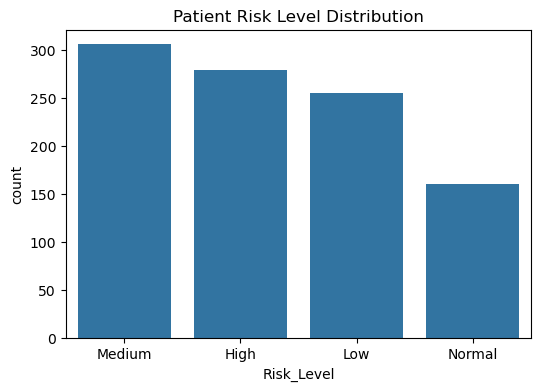

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Risk_Level",
    data=df
)

plt.title("Patient Risk Level Distribution")
plt.show()

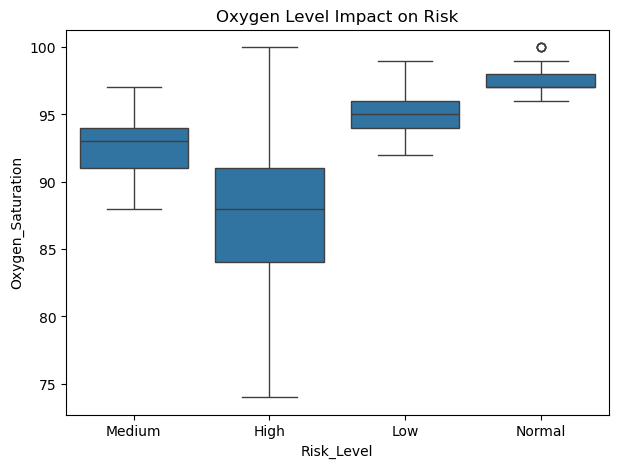

In [13]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="Risk_Level",
    y="Oxygen_Saturation",
    data=df
)

plt.title("Oxygen Level Impact on Risk")
plt.show()

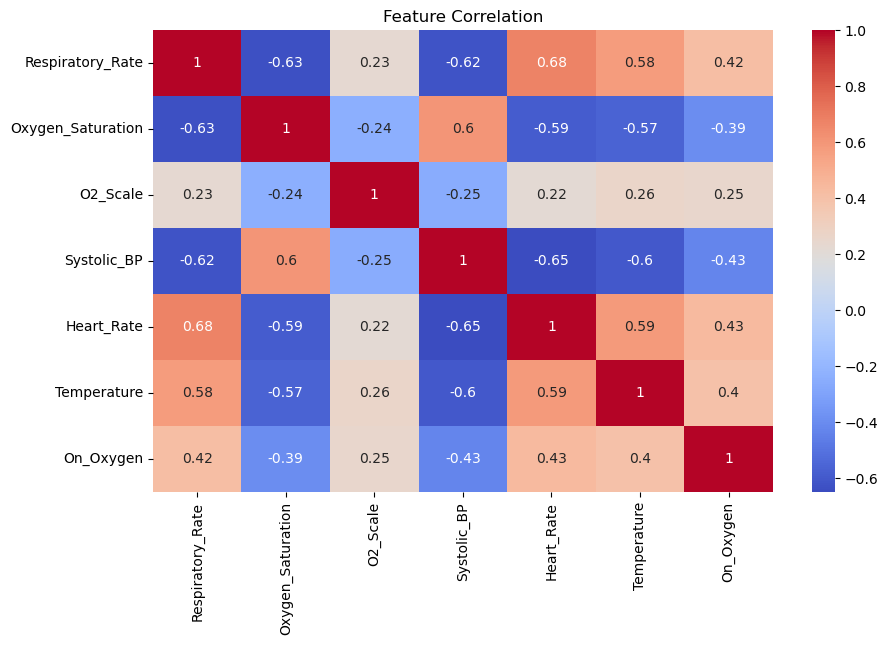

In [14]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")
plt.show()

In [15]:
df.select_dtypes(include="object").columns

Index(['Consciousness', 'Risk_Level'], dtype='object')

In [16]:
encoder = LabelEncoder()

for col in df.select_dtypes(include="object"):
    df[col] = encoder.fit_transform(df[col])

In [17]:
X = df.drop("Risk_Level", axis=1)

y = df["Risk_Level"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [20]:
lr = LogisticRegression()

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(X_test)

print(
    accuracy_score(
        y_test,
        lr_pred
    )
)

0.96


In [21]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)


print(
    "Accuracy:",
    accuracy_score(
        y_test,
        rf_pred
    )
)

Accuracy: 0.98


In [22]:
print(
classification_report(
    y_test,
    rf_pred
)
)

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        58
           1       0.96      0.98      0.97        45
           2       0.96      0.96      0.96        57
           3       1.00      1.00      1.00        40

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



In [23]:
importance = pd.DataFrame({

"Feature":X.columns,

"Importance":rf.feature_importances_

})


importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
1,Oxygen_Saturation,0.228234
4,Heart_Rate,0.198615
3,Systolic_BP,0.190206
0,Respiratory_Rate,0.168875
5,Temperature,0.168286
7,On_Oxygen,0.024334
2,O2_Scale,0.010741
6,Consciousness,0.010708


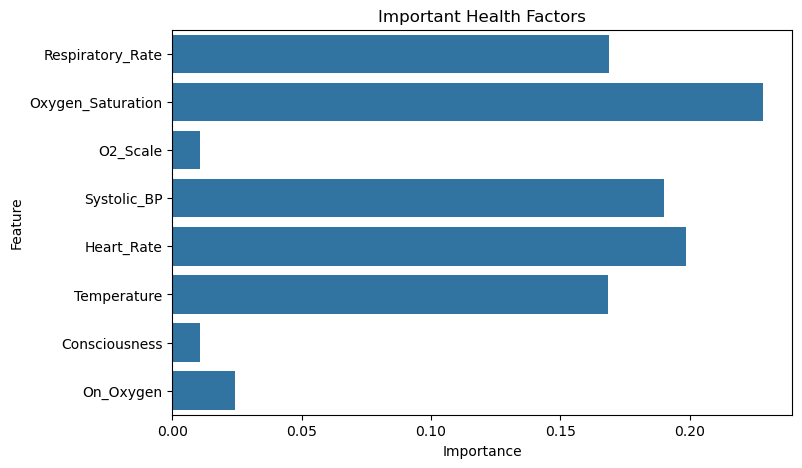

In [24]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title(
"Important Health Factors"
)

plt.show()